## Lab 1 Part A: OOP Search Algorithms for Drone Pathfinding

### 1. Setup and Imports

In [252]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### 2. The Abstract Problem Interface

In [253]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

### 3. The Node Class

In [254]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

### 4. Helper Functions

In [255]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    # return pd.DataFrame([result_to_row(r) for r in results])

### 5. Implementing the Grid Search Problem

In [256]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        row, col = state
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        for action, (dr, dc) in MOVES.items():
        #       a. Compute the neighbour cell.
          neighbor = (row + dr, col + dc)
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
          if self.in_bounds(neighbor) and self.is_free(neighbor):
        #       d. If valid, add the action name to legal_actions.
            legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        raise NotImplementedError("Complete GridProblem.action_cost")

#### 5.1 Self-Check for GridProblem

In [257]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


### 6. Sample Drone Map

In [258]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

### 7. Visualisation Helper

In [259]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

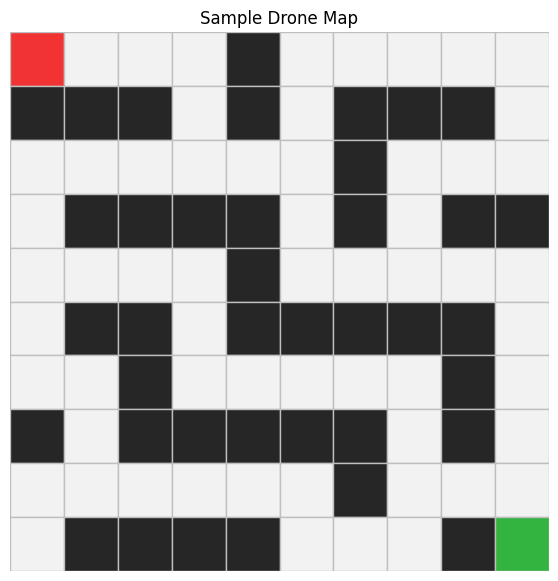

In [260]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

### 8. The Shared expand Method

In [261]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
        #     s_prime <- problem.RESULT(s, action)
          s_prime = problem.result(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
          yield Node(state = s_prime, parent = node, action=action, path_cost=cost)

        # raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

### 9. Breadth-First Search (BFS)

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
  def search(self, problem: Problem) -> SearchResult:
    algorithm = "BFS"

    # TODO 6:
    # Implement BFS graph search using a FIFO queue.
    #
    # Steps:
    # 1. Create the initial node from problem.initial_state().
    node = Node(problem.initial_state())
    # 2. If the initial state is the goal, return success.
    if(problem.is_goal(node.state)):
        return SearchResult(
          algorithm="BFS",
          status="success",
          solution=node,          # <-- This passes the goal node so the path can be reconstructed
          nodes_expanded=nodes_expanded,
          max_frontier_size=max_frontier_size,
          reached_count=len(reached)
        )
        # return node
    # 3. Create a deque frontier and add the initial node.
    frontier = deque([node])
    # 4. Create a reached set and add the initial state.
    reached = {problem.initial_state()}
    nodes_expanded = 0
    max_frontier_size = 1
    # 5. While frontier is not empty:
    while(frontier):
    #       a. pop from the LEFT of the deque.
      node = frontier.popleft()
    #       b. increment nodes_expanded.
      nodes_expanded += 1
    #       c. expand the node.
    #       d. for each child:
    for child in self.expand(problem, node):
    #            i. if child is goal, return success.
      if problem.is_goal(child.state):
        return SearchResult(
          algorithm=algorithm,
          status="success",
          solution=child,
          nodes_expanded=nodes_expanded,
          max_frontier_size=max_frontier_size if 'max_frontier_size' in locals() else len(frontier),
          reached_count=len(reached),
        )
    #           ii. if child.state is not in reached:
      if child.state not in reached:
    #                  add child.state to reached.
        reached.add(child.state)
    #                  append child to frontier.
        frontier.append(child)
    #       e. update max_frontier_size.
    max_frontier_size = max(max_frontier_size, len(frontier))
    # 6. Return failure if no solution is found.
    return SearchResult(
      algorithm=algorithm,
      status="failure",
      solution=None,
      nodes_expanded=nodes_expanded,
      max_frontier_size=max_frontier_size,
      reached_count=len(reached),
    )
    # Hint:
    # frontier = deque([node])
    # node = frontier.popleft()
    raise NotImplementedError("Complete BreadthFirstSearch.search")

### 10. Depth-First Search (DFS)

In [263]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
          return SearchResult(
            algorithm=algorithm,
            status="success",
            solution=node,
            nodes_expanded=0,
            max_frontier_size=1,
            reached_count=1,
          )
        # 3. Use a Python list as the stack frontier.
        frontier = [node]
        # 4. Use a reached set.
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the end of the list.
          node = frontier.pop()
        #       b. increment nodes_expanded.
          nodes_expanded += 1

        #       c. expand the node.
          children = list(self.expand(problem, node))
        #       d. add unreached children to the stack.
          for child in reversed(children):
            if child.state not in reached:
                reached.add(child.state)

            if problem.is_goal(child.state):
              return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=child,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max(max_frontier_size, len(frontier)),
                reached_count=len(reached),
              )

            frontier.append(child)

        #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))

          return SearchResult(
              algorithm=algorithm,
              status="failure",
              solution=None,
              nodes_expanded=nodes_expanded,
              max_frontier_size=max_frontier_size,
              reached_count=len(reached),
          )
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        raise NotImplementedError("Complete DepthFirstSearch.search")

### 11. Depth-Limited Search (DLS)

In [264]:
class DepthLimitedSearch(SearchAlgorithm):
  def search(self, problem: Problem, limit: int = 10) -> SearchResult:
    algorithm = "DLS"

    initial_node = Node(problem.initial_state())

    metrics = {
      "nodes_expanded": 0,
      "max_stack_size": 1,
    }

    solution, status = self._recursive_dls(
      problem=problem,
      node=initial_node,
      limit=limit,
      metrics=metrics,
      current_stack_size=1,
    )

    return SearchResult(
      algorithm=algorithm,
      status=status,
      solution=solution,
      nodes_expanded=metrics["nodes_expanded"],
      max_frontier_size=metrics["max_stack_size"],
      reached_count=0,
      limit=limit,
    )

  def _recursive_dls(
      self,
      problem: Problem,
      node: Node,
      limit: int,
      metrics: Dict[str, int],
      current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
    # TODO 8:
    # Implement recursive depth-limited search.
    #
    # Steps:
    # 1. If node.state is goal, return (node, "success").
    if(problem.is_goal(node.state)):
      return node, "success"
    # 2. Else if node.depth >= limit, return (None, "cutoff").
    elif(node.depth >= limit):
      return None, "cutoff"
    # 3. Otherwise:
    else:
    #       a. increment metrics["nodes_expanded"].
      metrics["nodes_expanded"] += 1
    #       b. set cutoff_occurred = False.
      cutoff_occurred = False
    #       c. for each child in expand(problem, node):
      for child in self.expand(problem, node):
    #             i. skip the child if child.state already appears on the current path.
        if state_is_on_path(node, child.state):
          continue
    #            ii. update max_stack_size.
        next_stack_size = current_stack_size + 1
        metrics["max_stack_size"] = max(metrics["max_stack_size"], next_stack_size)
    #           iii. recursively call _recursive_dls on the child.
        result_node, status = self._recursive_dls(
          problem=problem,
          node=child,
          limit=limit,
          metrics=metrics,
          current_stack_size=next_stack_size,
        )
    #            iv. if result is "success", return success immediately.
        if status == "success":
          return result_node, status
    #             v. if result is "cutoff", set cutoff_occurred = True.
        if status == "cutoff":
          cutoff_occurred = True
    #       d. after all children:
    return (None, "cutoff") if cutoff_occurred else (None, "failure")
    #             if cutoff_occurred, return (None, "cutoff")
    #             else return (None, "failure")
    # raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")


### 12. Iterative Deepening Search (IDS)

In [265]:
class IterativeDeepeningSearch(SearchAlgorithm):
  def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
    algorithm = "IDS"

    # TODO 9:
    # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
    #
    # Requirements:
    # 1. Keep a list called iteration_log.
    dls = DepthLimitedSearch()
    iteration_log = []
    # 2. Accumulate total nodes expanded across all DLS iterations.
    total_nodes_expanded = 0
    # 3. Track the maximum stack size seen in any DLS run.
    max_stack_size = 0

    for limit in range(max_depth + 1):
      result = dls.search(problem, limit=limit)

      iteration_log.append({
        "limit": limit,
        "status": result.status,
        "nodes_expanded": result.nodes_expanded,
        "max_stack_size": result.max_frontier_size,
        "solution_depth": result.solution_depth,
      })
      
      total_nodes_expanded += result.nodes_expanded
      # if result.max_frontier_size is not None:
      max_stack_size = max(max_stack_size, result.max_frontier_size or 0)

    # 4. If a DLS run returns success, return a SearchResult for IDS.
      if result.status == "success":
        return SearchResult(
          algorithm=algorithm,
          status="success",
          solution=result.solution,
          nodes_expanded=total_nodes_expanded,
          max_frontier_size=max_stack_size,
          reached_count=result.reached_count,
          limit=limit,
          iterations=iteration_log,
        )

    # 5. If a DLS run returns failure, IDS can stop early and return failure.
      if result.status == "failure":
        return SearchResult(
          algorithm=algorithm,
          status="failure",
          solution=None,
          nodes_expanded=total_nodes_expanded,
          max_frontier_size=max_stack_size,
          reached_count=result.reached_count,
          limit=limit,
          iterations=iteration_log,
        )

    # 6. If all limits return cutoff up to max_depth, return cutoff.
    return SearchResult(
      algorithm=algorithm,
      status="cutoff",
      solution=None,
      nodes_expanded=total_nodes_expanded,
      max_frontier_size=max_stack_size,
      reached_count=0,
      limit=max_depth,
      iterations=iteration_log,
    )
    #
    # Hint:
    # dls = DepthLimitedSearch()
    # result = dls.search(problem, limit=limit)
    raise NotImplementedError("Complete IterativeDeepeningSearch.search")

### 13. Run the Algorithms on the Sample Map

In [266]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
  bfs.search(problem),
  dfs.search(problem),
  dls.search(problem, limit=10),
  ids.search(problem, max_depth=30),
]

show_results(results)

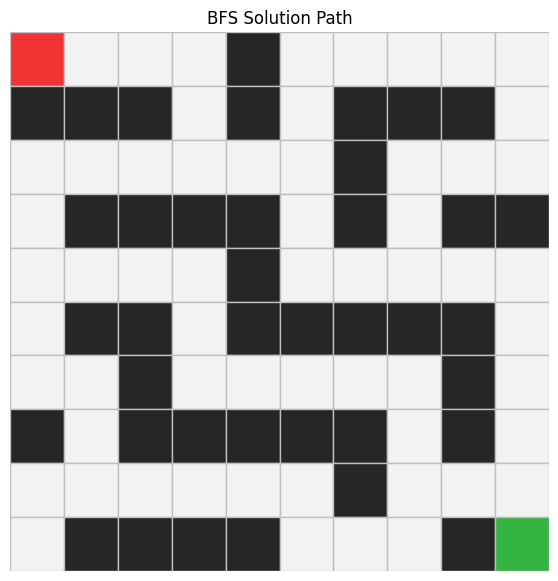

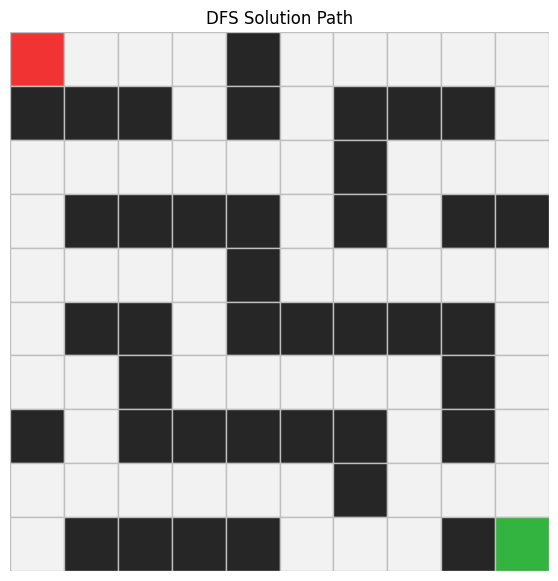

In [267]:

# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

### 14. Create Your Own Maps

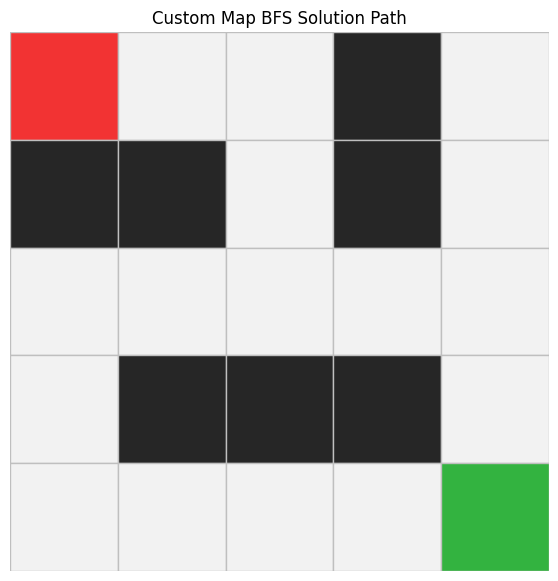

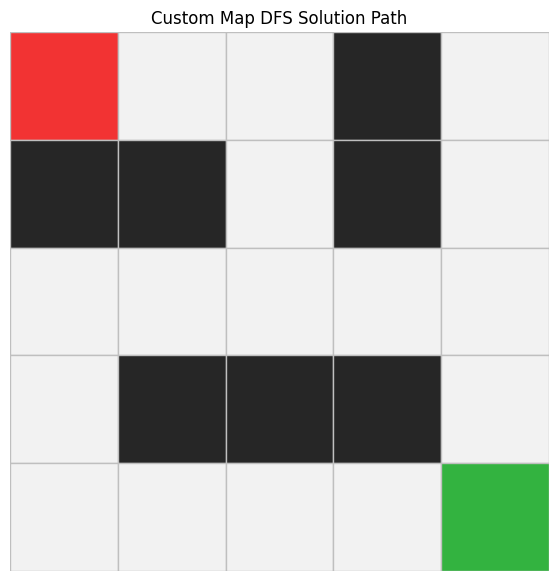

In [268]:

# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
  [0, 0, 0, 1, 0],
  [1, 1, 0, 1, 0],
  [0, 0, 0, 0, 0],
  [0, 1, 1, 1, 0],
  [0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (4, 4)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
custom_results_1 = [
  bfs.search(custom_problem_1),
  dfs.search(custom_problem_1),
  dls.search(custom_problem_1, limit=20),
  ids.search(custom_problem_1, max_depth=40),
]

# show_results(custom_results_1)
pd.DataFrame([result_to_row(r) for r in custom_results_1])

plot_path(
  custom_grid_1,
  custom_start_1,
  custom_goal_1,
  path=custom_results_1[0].path,
  title="Custom Map BFS Solution Path",
)

plot_path(
  custom_grid_1,
  custom_start_1,
  custom_goal_1,
  path=custom_results_1[1].path,
  title="Custom Map DFS Solution Path",
)

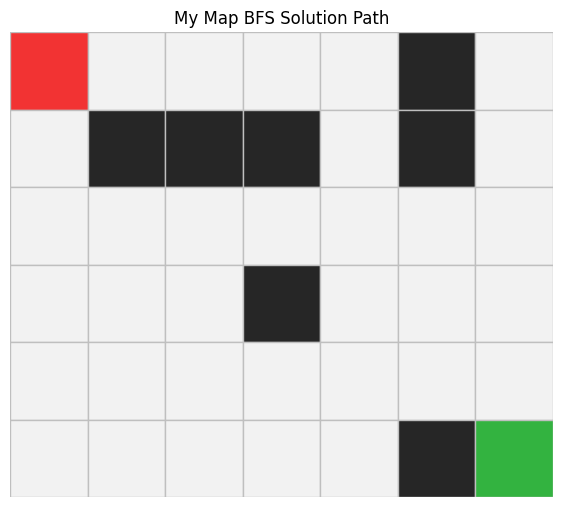

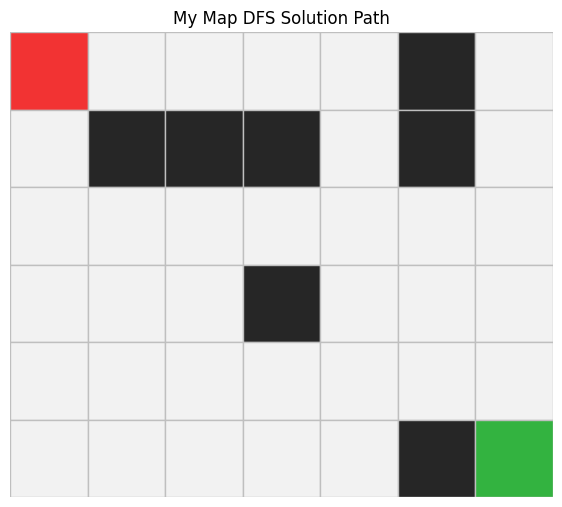

In [269]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,0,0,1,0],
    [0,1,1,1,0,1,0],
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (5, 6)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

pd.DataFrame([result_to_row(r) for r in custom_results_2])

plot_path(
  custom_grid_2,
  custom_start_2,
  custom_goal_2,
  path=custom_results_2[0].path,
  title="My Map BFS Solution Path",
)

plot_path(
  custom_grid_2,
  custom_start_2,
  custom_goal_2,
  path=custom_results_2[1].path,
  title="My Map DFS Solution Path",
)

### 15. Reflection Questions

#### 15.1 Problem Formulation

1. **Whart is a state in this lab?**  
*A state in this lab is the current position of the drone on the grid, represented as a tuple `(row, col)`.*

2. **What is an action?** 
*An action is a move direction the drone can take, such as `"UP"`, `"DOWN"`, `"LEFT"`, or `"RIGHT"`*.

3. **What does the result function do?**  
*The `result` function computes the next state after taking an action from a given state. In this lab it uses the move vector from `MOVES` to return the new grid position.*

4. **Why is it useful to separate the problem definition from the search algorithm?**  
*Separating the problem definition from the search algorithm is useful because it lets the same algorithms work on different problems, and lets you change the grid, start/goal, or move rules without changing the search code.*

#### 15.2 BFS
1. **Why does BFS use a FIFO queue?**  
*BFS uses a FIFO queue so it expands nodes in the order they were generated, exploring all nodes at one depth before moving to the next depth.*

2. **Why does BFS find the shortest path in terms of number of steps on the unweighted grid?**  
*Because every move has equal cost and BFS explores states by increasing depth, the first time it reaches the goal is through the fewest moves.*

3. **What role does the reached set play in BFS?**  
*The reached set prevents revisiting already seen states, avoiding repeated work and cycles in the graph search.*

#### 15.3 DFS
1. **Why does DFS use a stack?**  
*DFS uses a stack so it follows a path as deep as possible before backtracking, which is the natural behavior of depth-first search.*

2. **Is DFS guaranteed to find the shortest path? Explain.**  
*No. DFS is not guaranteed to find the shortest path because it may explore a deep branch and find a goal far from the root before exploring a shorter solution.*

3. **Under what conditions can DFS use less memory than BFS?**  
*DFS can use less memory when the search tree is wide but not very deep, because DFS only stores a single path plus siblings, while BFS stores an entire frontier of nodes at each depth.*

4. **Under what conditions can DFS perform badly?**  
*DFS performs badly when the search space has deep or infinite branches, or when the goal is shallow but located in a branch explored late.*

#### 15.4 DLS
1. **What happens when the depth limit is too small?**  
*When the depth limit is too small, DLS can fail to find a solution even if one exists, returning cutoff instead of success.*

2. **What is the meaning of "cutoff"?**  
*A cutoff means the search reached the depth limit on some branch without finding a goal, so the search was incomplete at that depth.*

3. **How is DLS different from ordinary DFS?**  
*DLS adds a maximum depth bound to DFS, stopping exploration beyond that limit even if the branch is not fully explored.*

4. **Why do we use path-cycle checking in DLS?**  
*Path-cycle checking prevents revisiting states already on the current path, avoiding infinite loops in cyclic graphs.*

#### 15.5 IDS
1. **Why does IDS repeat DLS with increasing limits?**  
*IDS repeats DLS with increasing limits to gradually explore deeper depths while still using limited memory, ensuring it eventually reaches the shallowest solution.*

2. **Why can IDS be complete even though DLS with a small limit is not?**  
*IDS is complete because it keeps increasing the depth limit until it reaches the depth of the solution, while DLS with a small fixed limit may stop too early.*

3. **Why does IDS use less memory than BFS?**  
*IDS uses less memory than BFS because it only stores the current path and stack for one depth-limited search at a time, instead of storing the full layer-by-layer frontier.*

4. **What is the cost of repeatedly searching from the root?**  
*The cost is repeated work: IDS revisits many nodes multiple times across increasing limits, which increases time complexity compared to a single search.*
